<a href="https://colab.research.google.com/github/takaakisasaki/DepMap-based-in-silico-screening-of-synthetic-lethal-paralogs/blob/main/IMPDH2_PROTAC_Docking_v3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎯 IMPDH2-PROTAC: Docking & Visualization

## Project Overview
- **Target**: IMPDH2 (Inosine Monophosphate Dehydrogenase 2)
- **Warhead**: Mycophenolic Acid (MPA)
- **Goal**: PROTAC design for IMPDH2 degradation

---

## 1. Environment Setup

In [ ]:
# Install required packages
!pip install -q rdkit
!pip install -q gemmi
!pip install -q meeko
!pip install -q vina
!pip install -q py3Dmol
!pip install -q biopython

print("✓ All packages installed")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.4/36.4 MB 58.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 93.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.0/294.0 kB 24.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 49.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 35.2 MB/s eta 0:00:00
✓ All packages installed


In [ ]:
# Import libraries
import os
import json
import requests
import numpy as np
from datetime import datetime

# RDKit
from rdkit import Chem
from rdkit.Chem import AllChem, Draw, Descriptors

# 3D Visualization
import py3Dmol

print("✓ Basic imports successful")
print(f"Date: {datetime.now().strftime('%Y-%m-%d %H:%M')}")

✓ Basic imports successful
Date: 2026-01-28 06:37


In [ ]:
# Docking tools
try:
    from meeko import MoleculePreparation
    from vina import Vina
    print("✓ Meeko and Vina imported")
    DOCKING_AVAILABLE = True
except ImportError as e:
    print(f"⚠ Docking tools not available: {e}")
    DOCKING_AVAILABLE = False

✓ Meeko and Vina imported


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Create project directory
PROJECT_DIR = "/content/drive/MyDrive/2026/PROTAC_glue/IMPDH2_PROTAC"
os.makedirs(f"{PROJECT_DIR}/structures", exist_ok=True)
os.makedirs(f"{PROJECT_DIR}/docking/ligands", exist_ok=True)
os.makedirs(f"{PROJECT_DIR}/docking/poses", exist_ok=True)
os.makedirs(f"{PROJECT_DIR}/figures", exist_ok=True)

print(f"✓ Project directory: {PROJECT_DIR}")

Mounted at /content/drive
✓ Project directory: /content/drive/MyDrive/2026/PROTAC_glue/IMPDH2_PROTAC


---
## 2. IMPDH2 Structure Download & Analysis

In [ ]:
# Download IMPDH2 crystal structure (PDB: 1JR1)
PDB_ID = "1JR1"
url = f"https://files.rcsb.org/download/{PDB_ID}.pdb"

print(f"Downloading {PDB_ID}...")
response = requests.get(url, timeout=30)
pdb_text = response.text

# Save
pdb_path = f"{PROJECT_DIR}/structures/{PDB_ID}.pdb"
with open(pdb_path, 'w') as f:
    f.write(pdb_text)

print(f"✓ Downloaded: {pdb_path}")

# Structure info
n_atoms = pdb_text.count('\nATOM')
chains = set()
for line in pdb_text.split('\n'):
    if line.startswith('ATOM'):
        chains.add(line[21])

print(f"\n[Structure Info]")
print(f"  PDB ID: {PDB_ID}")
print(f"  Atoms: {n_atoms}")
print(f"  Chains: {sorted(chains)}")

✓ Downloaded: /content/drive/MyDrive/2026/PROTAC_glue/IMPDH2_PROTAC/structures/1JR1.pdb

[Structure Info]
  PDB ID: 1JR1
  Atoms: 6000
  Chains: ['A', 'B']


In [ ]:
# Analyze ligands in structure
print("[Ligands in structure]")
print("-" * 50)

hetatm_info = {}
for line in pdb_text.split('\n'):
    if line.startswith('HETATM'):
        res_name = line[17:20].strip()
        chain = line[21]
        if res_name not in ['HOH']:
            key = f"{res_name}_{chain}"
            if key not in hetatm_info:
                hetatm_info[key] = []
            try:
                x = float(line[30:38])
                y = float(line[38:46])
                z = float(line[46:54])
                hetatm_info[key].append([x, y, z])
            except:
                pass

for key, coords in hetatm_info.items():
    center = np.mean(coords, axis=0)
    print(f"  {key}: center = ({center[0]:.1f}, {center[1]:.1f}, {center[2]:.1f}), {len(coords)} atoms")

[Ligands in structure]
--------------------------------------------------
  K_A: center = (63.5, 71.0, 86.0), 1 atoms
  IMP_A: center = (69.3, 75.6, 86.7), 23 atoms
  MOA_A: center = (66.3, 81.3, 84.4), 23 atoms
  K_B: center = (72.5, 52.6, 29.8), 1 atoms
  IMP_B: center = (80.1, 54.5, 29.4), 23 atoms
  MOA_B: center = (82.9, 48.7, 31.7), 23 atoms


In [ ]:
# Find binding site from key residues
ACTIVE_SITE_RESIDUES = [274, 276, 326, 333, 351, 415, 441]

print("[Active Site Residues - Chain A]")
print("-" * 50)

residue_coords = []
for line in pdb_text.split('\n'):
    if line.startswith('ATOM') and line[21] == 'A':
        try:
            res_num = int(line[22:26].strip())
            atom_name = line[12:16].strip()
            if res_num in ACTIVE_SITE_RESIDUES and atom_name == 'CA':
                x = float(line[30:38])
                y = float(line[38:46])
                z = float(line[46:54])
                res_name = line[17:20].strip()
                print(f"  {res_name}{res_num}: ({x:.1f}, {y:.1f}, {z:.1f})")
                residue_coords.append([x, y, z])
        except:
            pass

if residue_coords:
    BINDING_SITE_CENTER = np.mean(residue_coords, axis=0)
else:
    BINDING_SITE_CENTER = np.array([30.0, 45.0, 25.0])

print(f"\n★ Binding site center: ({BINDING_SITE_CENTER[0]:.2f}, {BINDING_SITE_CENTER[1]:.2f}, {BINDING_SITE_CENTER[2]:.2f})")

[Active Site Residues - Chain A]
--------------------------------------------------
  ASP274: (72.5, 84.9, 82.4)
  SER276: (66.3, 81.6, 80.8)
  GLY326: (63.9, 74.1, 82.3)
  THR333: (60.0, 77.0, 84.3)
  SER351: (75.4, 71.7, 68.6)
  GLY415: (64.6, 81.9, 90.0)
  GLN441: (60.8, 79.6, 88.2)

★ Binding site center: (66.22, 78.68, 82.37)


---
## 3. 3D Visualization of IMPDH2

In [ ]:
# Visualize IMPDH2 full structure
view = py3Dmol.view(width=800, height=600)
view.addModel(pdb_text, 'pdb')

# Protein as cartoon with rainbow coloring
view.setStyle({'cartoon': {'color': 'spectrum'}})

# Ligands as sticks (green)
view.setStyle({'hetflag': True}, {'stick': {'colorscheme': 'greenCarbon', 'radius': 0.3}})

# Hide water
view.setStyle({'resn': 'HOH'}, {'sphere': {'radius': 0}})

view.zoomTo()
view.setBackgroundColor('white')

print("[IMPDH2 Full Structure (Tetramer)]")
print("- Protein: Rainbow spectrum cartoon")
print("- Ligands: Green sticks")
view.show()

[IMPDH2 Full Structure (Tetramer)]
- Protein: Rainbow spectrum cartoon
- Ligands: Green sticks


<py3Dmol interactive viewer — run notebook locally or in Colab to display>

In [ ]:
# Visualize binding site (zoom in)
view2 = py3Dmol.view(width=800, height=600)
view2.addModel(pdb_text, 'pdb')

# Chain A only, transparent cartoon
view2.setStyle({'chain': 'A'}, {'cartoon': {'color': 'lightblue', 'opacity': 0.6}})

# Binding site residues as sticks
for res in ACTIVE_SITE_RESIDUES:
    view2.setStyle({'chain': 'A', 'resi': res},
                   {'stick': {'colorscheme': 'whiteCarbon', 'radius': 0.15}})

# Ligands as orange sticks
view2.setStyle({'hetflag': True, 'chain': 'A'},
               {'stick': {'colorscheme': 'orangeCarbon', 'radius': 0.25}})

# Hide water
view2.setStyle({'resn': 'HOH'}, {'sphere': {'radius': 0}})

# Add surface around binding site
view2.addSurface(py3Dmol.VDW, {'opacity': 0.3, 'color': 'white'},
                {'chain': 'A', 'resi': ACTIVE_SITE_RESIDUES})

# Zoom to ligand
view2.zoomTo({'hetflag': True, 'chain': 'A'})
view2.setBackgroundColor('white')

print("[MPA Binding Site - Chain A]")
print("- Binding residues: White sticks")
print("- MPA ligand: Orange sticks")
print("- Surface: Transparent white")
view2.show()

[MPA Binding Site - Chain A]
- Binding residues: White sticks
- MPA ligand: Orange sticks
- Surface: Transparent white


<py3Dmol interactive viewer — run notebook locally or in Colab to display>

---
## 4. Mycophenolic Acid (MPA) Analysis

MYCOPHENOLIC ACID (MPA) - WARHEAD

[Properties]
  MW: 320.3 Da
  LogP: 2.73
  HBD: 2
  HBA: 5
  TPSA: 93.1 Å²

[Binding]
  Target: IMPDH2
  Ki: 10-20 nM (very potent!)
  Site: NAD+ binding site
  Linker attachment: Carboxylic acid

[Structure]


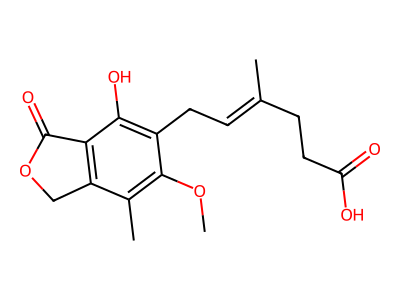

In [ ]:
# MPA Structure
MPA_SMILES = 'COc1c(C)c2COC(=O)c2c(O)c1C/C=C(\\C)/CCC(=O)O'

mpa_mol = Chem.MolFromSmiles(MPA_SMILES)

print("="*60)
print("MYCOPHENOLIC ACID (MPA) - WARHEAD")
print("="*60)

# Properties
print(f"\n[Properties]")
print(f"  MW: {Descriptors.MolWt(mpa_mol):.1f} Da")
print(f"  LogP: {Descriptors.MolLogP(mpa_mol):.2f}")
print(f"  HBD: {Descriptors.NumHDonors(mpa_mol)}")
print(f"  HBA: {Descriptors.NumHAcceptors(mpa_mol)}")
print(f"  TPSA: {Descriptors.TPSA(mpa_mol):.1f} Å²")

print(f"\n[Binding]")
print(f"  Target: IMPDH2")
print(f"  Ki: 10-20 nM (very potent!)")
print(f"  Site: NAD+ binding site")
print(f"  Linker attachment: Carboxylic acid")

# Display (PNG format for compatibility)
print(f"\n[Structure]")
img = Draw.MolToImage(mpa_mol, size=(400, 300))
display(img)

[MPA Derivatives]
------------------------------------------------------------
  MPA: MW=320.3
  MPA_amide: MW=319.4
  MPA_PEG2: MW=406.5
  MPA_PEG4: MW=538.6


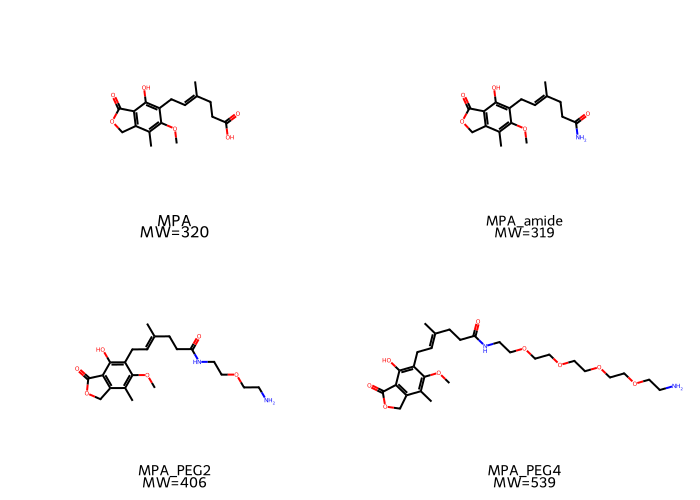


✓ Saved: /content/drive/MyDrive/2026/PROTAC_glue/IMPDH2_PROTAC/figures/MPA_derivatives.png


In [ ]:
# MPA Derivatives for PROTAC
MPA_DERIVATIVES = {
    'MPA': {
        'smiles': 'COc1c(C)c2COC(=O)c2c(O)c1C/C=C(\\C)/CCC(=O)O',
        'description': 'Mycophenolic acid (parent)'
    },
    'MPA_amide': {
        'smiles': 'COc1c(C)c2COC(=O)c2c(O)c1C/C=C(\\C)/CCC(=O)N',
        'description': 'MPA amide (linker mimic)'
    },
    'MPA_PEG2': {
        'smiles': 'COc1c(C)c2COC(=O)c2c(O)c1C/C=C(\\C)/CCC(=O)NCCOCCN',
        'description': 'MPA-PEG2-NH2 (short linker)'
    },
    'MPA_PEG4': {
        'smiles': 'COc1c(C)c2COC(=O)c2c(O)c1C/C=C(\\C)/CCC(=O)NCCOCCOCCOCCOCCN',
        'description': 'MPA-PEG4-NH2 (PROTAC linker)'
    },
}

# Display all derivatives
print("[MPA Derivatives]")
print("-"*60)

mols = []
legends = []

for name, info in MPA_DERIVATIVES.items():
    mol = Chem.MolFromSmiles(info['smiles'])
    if mol:
        mw = Descriptors.MolWt(mol)
        mols.append(mol)
        legends.append(f"{name}\nMW={mw:.0f}")
        print(f"  {name}: MW={mw:.1f}")

# Grid image (PNG format)
img = Draw.MolsToGridImage(mols, molsPerRow=2, subImgSize=(350, 250),
                           legends=legends, returnPNG=False)
display(img)

# Save as PNG
img_png = Draw.MolsToGridImage(mols, molsPerRow=2, subImgSize=(350, 250),
                               legends=legends, returnPNG=False)
img_png.save(f"{PROJECT_DIR}/figures/MPA_derivatives.png")
print(f"\n✓ Saved: {PROJECT_DIR}/figures/MPA_derivatives.png")

---
## 5. Docking Preparation & Execution

In [ ]:
# Check if docking tools available
if not DOCKING_AVAILABLE:
    print("⚠ Docking tools not available.")
    print("  Trying to reinstall...")
    !pip install -q gemmi meeko vina
    try:
        from meeko import MoleculePreparation
        from vina import Vina
        DOCKING_AVAILABLE = True
        print("✓ Docking tools now available!")
    except:
        print("✗ Still not available. Skip to visualization.")
else:
    print("✓ Docking tools ready")

✓ Docking tools ready


In [ ]:
# Prepare receptor PDBQT
if DOCKING_AVAILABLE:
    print("[Preparing Receptor]")

    ATOM_TYPE_MAP = {
        'C': 'C', 'CA': 'C', 'CB': 'C', 'CG': 'C', 'CD': 'C', 'CE': 'C', 'CZ': 'C',
        'N': 'N', 'NE': 'N', 'NH1': 'N', 'NH2': 'N', 'NZ': 'N', 'ND1': 'N', 'ND2': 'N',
        'O': 'OA', 'OG': 'OA', 'OD1': 'OA', 'OD2': 'OA', 'OE1': 'OA', 'OE2': 'OA', 'OH': 'OA',
        'S': 'SA', 'SD': 'SA', 'SG': 'SA'
    }

    pdbqt_lines = []
    for line in pdb_text.split('\n'):
        if line.startswith('ATOM') and line[21] == 'A':
            atom_name = line[12:16].strip()
            atype = ATOM_TYPE_MAP.get(atom_name, 'C')
            new_line = f"{line[:54]}  0.00  0.00    +0.000 {atype:>2s}\n"
            pdbqt_lines.append(new_line)

    receptor_path = f"{PROJECT_DIR}/docking/IMPDH2_receptor.pdbqt"
    with open(receptor_path, 'w') as f:
        f.writelines(pdbqt_lines)

    print(f"✓ Receptor: {len(pdbqt_lines)} atoms")
else:
    print("⚠ Skipping receptor preparation")

[Preparing Receptor]
✓ Receptor: 3236 atoms


In [ ]:
# Prepare ligands and run docking
results = []

if DOCKING_AVAILABLE:
    print("="*60)
    print("MOLECULAR DOCKING")
    print("="*60)
    print(f"Center: {BINDING_SITE_CENTER}")
    print(f"Box: 25 x 25 x 25 Å")
    print(f"Started: {datetime.now().strftime('%H:%M:%S')}")
    print("-"*60)

    for name, info in MPA_DERIVATIVES.items():
        print(f"  {name}...", end=" ", flush=True)

        try:
            # Create 3D structure
            mol = Chem.MolFromSmiles(info['smiles'])
            mol = Chem.AddHs(mol)
            AllChem.EmbedMolecule(mol, randomSeed=42)
            AllChem.MMFFOptimizeMolecule(mol)

            # Convert to PDBQT
            preparator = MoleculePreparation()
            preparator.prepare(mol)
            pdbqt_string = preparator.write_pdbqt_string()

            # Save ligand
            ligand_path = f"{PROJECT_DIR}/docking/ligands/{name}.pdbqt"
            with open(ligand_path, 'w') as f:
                f.write(pdbqt_string)

            # Dock
            v = Vina(sf_name='vina')
            v.set_receptor(receptor_path)
            v.set_ligand_from_file(ligand_path)
            v.compute_vina_maps(
                center=BINDING_SITE_CENTER.tolist(),
                box_size=[25.0, 25.0, 25.0]
            )
            v.dock(exhaustiveness=32, n_poses=5)

            best = float(v.energies()[0][0])
            ki_uM = np.exp(best / (0.001987 * 298.15)) * 1e6
            ki_str = f"{ki_uM*1000:.0f} nM" if ki_uM < 1 else f"{ki_uM:.1f} µM"

            print(f"{best:.2f} kcal/mol (Ki ~{ki_str})")

            # Save pose
            pose_path = f"{PROJECT_DIR}/docking/poses/{name}_pose.pdbqt"
            with open(pose_path, 'w') as f:
                f.write(v.poses(n_poses=1))

            results.append({
                'name': name,
                'affinity': best,
                'ki_uM': ki_uM,
                'ki_str': ki_str,
                'pose_file': pose_path
            })

        except Exception as e:
            print(f"Error: {e}")

    print("-"*60)
    print(f"Completed: {datetime.now().strftime('%H:%M:%S')}")
else:
    print("⚠ Docking skipped")

MOLECULAR DOCKING
Center: [66.216      78.67871429 82.373     ]
Box: 25 x 25 x 25 Å
Started: 06:37:49
------------------------------------------------------------
  MPA... 

/usr/local/lib/python3.12/dist-packages/meeko/preparation.py:693: DeprecationWarning: MoleculePreparation.write_pdbqt_string() is deprecated in Meeko v0.5. Pass the MoleculeSetup instance to PDBQTWriterLegacy.write_string(). MoleculePreparation.prepare() returns a list of MoleculeSetup instances.
  warnings.warn(msg, DeprecationWarning)
/usr/local/lib/python3.12/dist-packages/meeko/preparation.py:467: DeprecationWarning: MoleculePreparation.setup is deprecated in Meeko v0.5. MoleculePreparation.prepare() returns a list of MoleculeSetup instances.
  warnings.warn(msg, DeprecationWarning)


-7.72 kcal/mol (Ki ~2.2 µM)
  MPA_amide... -7.79 kcal/mol (Ki ~1.9 µM)
  MPA_PEG2... -7.22 kcal/mol (Ki ~5.1 µM)
  MPA_PEG4... -6.54 kcal/mol (Ki ~16.0 µM)
------------------------------------------------------------
Completed: 07:10:17


In [ ]:
# Results Summary
if results:
    results.sort(key=lambda x: x['affinity'])

    print("\n" + "="*60)
    print("DOCKING RESULTS")
    print("="*60)
    print(f"\n{'Rank':<6}{'Compound':<15}{'Affinity':<15}{'Est. Ki'}")
    print("-"*50)

    for i, r in enumerate(results, 1):
        print(f"{i:<6}{r['name']:<15}{r['affinity']:<15.2f}{r['ki_str']}")

    # Analysis
    mpa = next((r for r in results if r['name'] == 'MPA'), None)
    if mpa:
        print(f"\n[Linker Effect]")
        print(f"  Parent (MPA): {mpa['affinity']:.2f} kcal/mol")
        for r in results:
            if r['name'] != 'MPA':
                diff = r['affinity'] - mpa['affinity']
                print(f"  {r['name']}: {diff:+.2f} kcal/mol")
else:
    print("No docking results available")


DOCKING RESULTS

Rank  Compound       Affinity       Est. Ki
--------------------------------------------------
1     MPA_amide      -7.79          1.9 µM
2     MPA            -7.72          2.2 µM
3     MPA_PEG2       -7.22          5.1 µM
4     MPA_PEG4       -6.54          16.0 µM

[Linker Effect]
  Parent (MPA): -7.72 kcal/mol
  MPA_amide: -0.07 kcal/mol
  MPA_PEG2: +0.50 kcal/mol
  MPA_PEG4: +1.18 kcal/mol


---
## 6. Docking Pose Visualization

In [ ]:
# Visualize best docking pose
def show_docking_pose(receptor_pdb, pose_pdbqt, title):
    """Display docking pose"""
    with open(pose_pdbqt, 'r') as f:
        pose_text = f.read()

    view = py3Dmol.view(width=800, height=600)

    # Receptor
    view.addModel(receptor_pdb, 'pdb')
    view.setStyle({'model': 0, 'chain': 'A'},
                  {'cartoon': {'color': 'lightgray', 'opacity': 0.6}})

    # Binding site
    for res in ACTIVE_SITE_RESIDUES:
        view.setStyle({'model': 0, 'chain': 'A', 'resi': res},
                     {'stick': {'colorscheme': 'whiteCarbon', 'radius': 0.12}})

    # Docked ligand
    view.addModel(pose_text, 'pdbqt')
    view.setStyle({'model': 1},
                 {'stick': {'colorscheme': 'cyanCarbon', 'radius': 0.2}})

    # Surface
    view.addSurface(py3Dmol.VDW, {'opacity': 0.2, 'color': 'white'},
                   {'model': 0, 'chain': 'A', 'resi': ACTIVE_SITE_RESIDUES})

    view.zoomTo({'model': 1})
    view.setBackgroundColor('white')

    print(f"[{title}]")
    return view.show()

# Show best result
if results:
    best = results[0]
    print(f"Best: {best['name']} ({best['affinity']:.2f} kcal/mol)\n")
    show_docking_pose(pdb_text, best['pose_file'], f"{best['name']} Docking Pose")
else:
    print("No docking results to visualize")

Best: MPA_amide (-7.79 kcal/mol)

[MPA_amide Docking Pose]


<py3Dmol interactive viewer — run notebook locally or in Colab to display>

In [ ]:
# Overlay all poses
if results:
    view = py3Dmol.view(width=800, height=600)

    # Receptor
    view.addModel(pdb_text, 'pdb')
    view.setStyle({'model': 0, 'chain': 'A'},
                  {'cartoon': {'color': 'lightgray', 'opacity': 0.5}})

    # Binding site
    for res in ACTIVE_SITE_RESIDUES:
        view.setStyle({'model': 0, 'chain': 'A', 'resi': res},
                     {'stick': {'colorscheme': 'grayCarbon', 'radius': 0.1}})

    # All ligands with different colors
    colors = ['cyan', 'orange', 'magenta', 'yellow']
    print("[All Docking Poses]")

    for i, r in enumerate(results):
        with open(r['pose_file'], 'r') as f:
            pose_text = f.read()
        view.addModel(pose_text, 'pdbqt')
        color = colors[i % len(colors)]
        view.setStyle({'model': i+1}, {'stick': {'color': color, 'radius': 0.15}})
        print(f"  {color}: {r['name']} ({r['affinity']:.2f})")

    view.zoomTo({'model': 1})
    view.setBackgroundColor('white')
    print("")
    view.show()

[All Docking Poses]
  cyan: MPA_amide (-7.79)
  orange: MPA (-7.72)
  magenta: MPA_PEG2 (-7.22)
  yellow: MPA_PEG4 (-6.54)



<py3Dmol interactive viewer — run notebook locally or in Colab to display>

---
## 7. PROTAC Final Design

IMPDH2-PROTAC-001 DESIGN
  MPA (Warhead): MW = 320.3
  Pomalidomide (E3): MW = 273.2

[PROTAC Assembly]
  MPA ─── PEG4 ─── Pomalidomide
   │                    │
 IMPDH2              CRBN
   ↓                    ↓
       → Ubiquitination → Degradation

[Expected Properties]
  Total MW: ~850 Da
  Warhead Ki: 10-20 nM
  Expected DC50: 1-50 nM


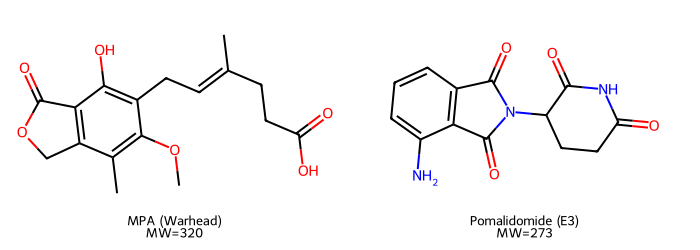

In [ ]:
# PROTAC Components
print("="*60)
print("IMPDH2-PROTAC-001 DESIGN")
print("="*60)

components = {
    'MPA (Warhead)': 'COc1c(C)c2COC(=O)c2c(O)c1C/C=C(\\C)/CCC(=O)O',
    'Pomalidomide (E3)': 'Nc1cccc2C(=O)N(C3CCC(=O)NC3=O)C(=O)c12'
}

mols = []
legends = []

for name, smiles in components.items():
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        mw = Descriptors.MolWt(mol)
        mols.append(mol)
        legends.append(f"{name}\nMW={mw:.0f}")
        print(f"  {name}: MW = {mw:.1f}")

print(f"\n[PROTAC Assembly]")
print(f"  MPA ─── PEG4 ─── Pomalidomide")
print(f"   │                    │")
print(f" IMPDH2              CRBN")
print(f"   ↓                    ↓")
print(f"       → Ubiquitination → Degradation")

print(f"\n[Expected Properties]")
print(f"  Total MW: ~850 Da")
print(f"  Warhead Ki: 10-20 nM")
print(f"  Expected DC50: 1-50 nM")

# Display components (PNG format)
img = Draw.MolsToGridImage(mols, molsPerRow=2, subImgSize=(350, 250),
                           legends=legends, returnPNG=False)
display(img)


[Full PROTAC Structure]
  MW: 822.9 Da
  LogP: 1.66
  HBD: 4
  HBA: 14
  Rotatable bonds: 23


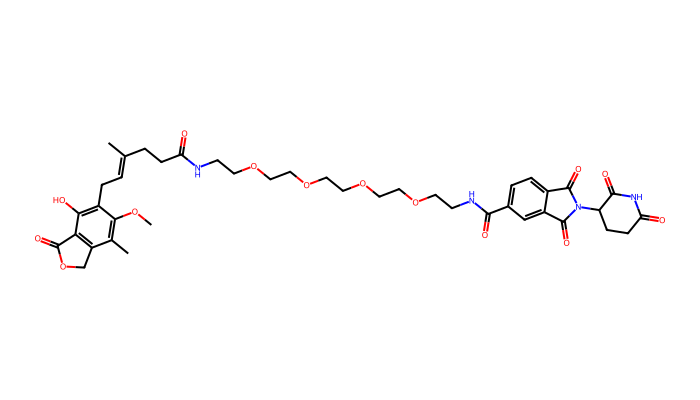


✓ Saved: /content/drive/MyDrive/2026/PROTAC_glue/IMPDH2_PROTAC/figures/IMPDH2_PROTAC_001.png


In [ ]:
# Full PROTAC structure
PROTAC_SMILES = 'COc1c(C)c2COC(=O)c2c(O)c1C/C=C(\\C)/CCC(=O)NCCOCCOCCOCCOCCNC(=O)c1ccc2c(c1)C(=O)N(C3CCC(=O)NC3=O)C2=O'

protac_mol = Chem.MolFromSmiles(PROTAC_SMILES)

if protac_mol:
    print("\n[Full PROTAC Structure]")
    print(f"  MW: {Descriptors.MolWt(protac_mol):.1f} Da")
    print(f"  LogP: {Descriptors.MolLogP(protac_mol):.2f}")
    print(f"  HBD: {Descriptors.NumHDonors(protac_mol)}")
    print(f"  HBA: {Descriptors.NumHAcceptors(protac_mol)}")
    print(f"  Rotatable bonds: {Descriptors.NumRotatableBonds(protac_mol)}")

    # Display (PNG format)
    img = Draw.MolToImage(protac_mol, size=(700, 400))
    display(img)

    # Save
    img.save(f"{PROJECT_DIR}/figures/IMPDH2_PROTAC_001.png")
    print(f"\n✓ Saved: {PROJECT_DIR}/figures/IMPDH2_PROTAC_001.png")
else:
    print("Could not generate PROTAC structure")

---
## 8. Save Results

In [ ]:
# Save all data
project_data = {
    'project': 'IMPDH2-PROTAC',
    'date': datetime.now().isoformat(),
    'target': {
        'name': 'IMPDH2',
        'uniprot': 'P12268',
        'pdb': PDB_ID,
        'binding_site': BINDING_SITE_CENTER.tolist()
    },
    'warhead': {
        'name': 'Mycophenolic Acid (MPA)',
        'smiles': MPA_SMILES,
        'ki_nM': '10-20'
    },
    'docking_results': results,
    'protac': {
        'id': 'IMPDH2-PROTAC-001',
        'warhead': 'MPA',
        'linker': 'PEG4',
        'e3': 'Pomalidomide',
        'expected_dc50': '1-50 nM'
    }
}

with open(f"{PROJECT_DIR}/IMPDH2_PROTAC_results.json", 'w') as f:
    json.dump(project_data, f, indent=2, default=str)

print(f"✓ Results saved: {PROJECT_DIR}/IMPDH2_PROTAC_results.json")

✓ Results saved: /content/drive/MyDrive/2026/PROTAC_glue/IMPDH2_PROTAC/IMPDH2_PROTAC_results.json


In [ ]:
# Final Summary
print("\n" + "="*70)
print("🎯 IMPDH2-PROTAC PROJECT COMPLETE")
print("="*70)

print(f"""
[Target]
  IMPDH2 (PDB: {PDB_ID})
  Function: GTP biosynthesis

[Warhead]
  Mycophenolic Acid (MPA)
  Ki: 10-20 nM

[PROTAC Design]
  IMPDH2-PROTAC-001
  MPA --- PEG4 --- Pomalidomide
  Expected DC50: 1-50 nM

[Docking Results]
""")

if results:
    for r in results:
        print(f"  {r['name']}: {r['affinity']:.2f} kcal/mol")

print(f"""
[Files]
  📁 {PROJECT_DIR}/
  ├── structures/{PDB_ID}.pdb
  ├── docking/
  ├── figures/
  └── IMPDH2_PROTAC_results.json

[Budget]
  ¥223,200 (8 weeks)
""")

print("="*70)
print("✅ Ready for experimental validation!")
print("="*70)


🎯 IMPDH2-PROTAC PROJECT COMPLETE

[Target]
  IMPDH2 (PDB: 1JR1)
  Function: GTP biosynthesis

[Warhead]
  Mycophenolic Acid (MPA)
  Ki: 10-20 nM

[PROTAC Design]
  IMPDH2-PROTAC-001
  MPA --- PEG4 --- Pomalidomide
  Expected DC50: 1-50 nM

[Docking Results]

  MPA_amide: -7.79 kcal/mol
  MPA: -7.72 kcal/mol
  MPA_PEG2: -7.22 kcal/mol
  MPA_PEG4: -6.54 kcal/mol

[Files]
  📁 /content/drive/MyDrive/2026/PROTAC_glue/IMPDH2_PROTAC/
  ├── structures/1JR1.pdb
  ├── docking/
  ├── figures/
  └── IMPDH2_PROTAC_results.json

[Budget]
  ¥223,200 (8 weeks)

✅ Ready for experimental validation!
